## Phase 4 — NLP Exploratory Data Analysis (EDA)

### Import libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter

### Load the NLP dataset

In [4]:
file_path = "../data/processed/yelp_reviews_nlp.csv"

df = pd.read_csv(file_path)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (14351, 12)


,stars_review,text,date,name,categories,city,state,stars_business,review_count,rating_review,text_lower,clean_text
0,3,"If you decide to eat here, just be aware it is...",2018-07-07 22:09:00,Turning Point of North Wales,"Restaurants, Breakfast & Brunch, Food, Juice B...",North Wales,PA,3.0,169,Neutral,"if you decide to eat here, just be aware it is...",decide eat aware going take hour beginning end...
1,3,Family diner. Had the buffet. Eclectic assortm...,2014-02-05 20:30:00,Kettle Restaurant,"Restaurants, Breakfast & Brunch",Tucson,AZ,3.5,47,Neutral,family diner. had the buffet. eclectic assortm...,family diner buffet eclectic assortment large ...
2,5,"Wow! Yummy, different, delicious. Our favo...",2015-01-04 00:01:00,Zaika,"Halal, Pakistani, Restaurants, Indian",Philadelphia,PA,4.0,181,Positive,"wow! yummy, different, delicious. our favo...",wow yummy different delicious favorite lamb cu...
3,4,Cute interior and owner (?) gave us tour of up...,2017-01-14 20:54:00,Melt,"Sandwiches, Beer, Wine & Spirits, Bars, Food, ...",New Orleans,LA,4.0,32,Positive,cute interior and owner (?) gave us tour of up...,cute interior owner gave u tour upcoming patio...
4,1,I am a long term frequent customer of this est...,2015-09-23 23:10:00,Dmitri's,"Mediterranean, Restaurants, Seafood, Greek",Philadelphia,PA,4.0,273,Negative,i am a long term frequent customer of this est...,long term frequent customer establishment went...


### Check the sentiment distribution

In [5]:
print(df["rating_review"].value_counts())

rating_review
Positive    9857
Negative    2699
Neutral     1795
Name: count, dtype: int64


In [6]:
sentiment_percentage = (
    df["rating_review"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(sentiment_percentage)

rating_review
Positive    68.69
Negative    18.81
Neutral     12.51
Name: proportion, dtype: float64


### Visualize sentiment distribution

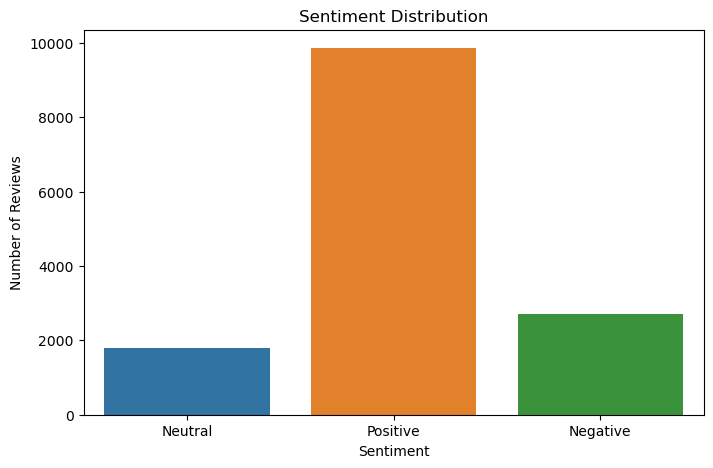

In [7]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="rating_review"
)

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")

plt.show()

### Calculate original review length

In [8]:
df["review_length"] = df["text"].str.len()

In [9]:
df[["text", "review_length"]].head()

,text,review_length
0,"If you decide to eat here, just be aware it is...",513
1,Family diner. Had the buffet. Eclectic assortm...,339
2,"Wow! Yummy, different, delicious. Our favo...",243
3,Cute interior and owner (?) gave us tour of up...,534
4,I am a long term frequent customer of this est...,341


### Review length statistics

In [10]:
print(df["review_length"].describe())

count    14351.000000
mean       536.809003
std        496.934693
min         18.000000
25%        217.000000
50%        382.000000
75%        675.000000
max       4994.000000
Name: review_length, dtype: float64


### Visualize review length

c:\Users\mahad\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


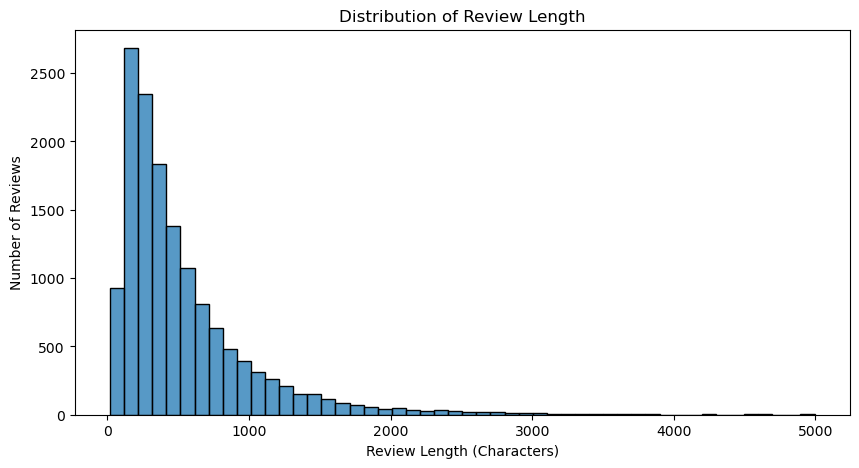

In [11]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="review_length",
    bins=50
)

plt.title("Distribution of Review Length")
plt.xlabel("Review Length (Characters)")
plt.ylabel("Number of Reviews")

plt.show()

### Review length by sentimentReview length by sentiment

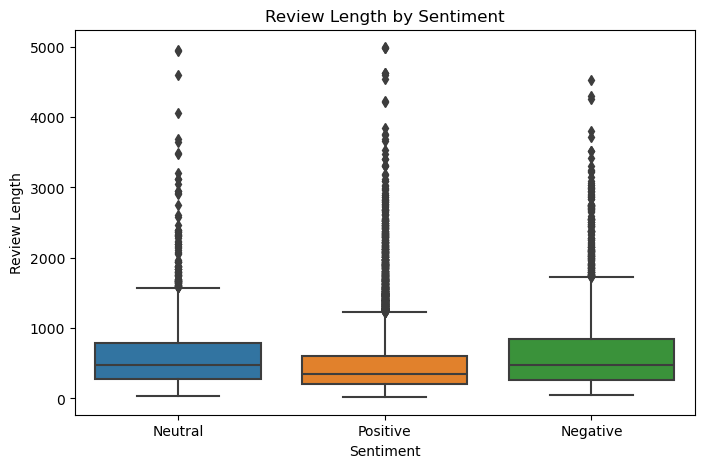

In [12]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="rating_review",
    y="review_length"
)

plt.title("Review Length by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Review Length")

plt.show()

### Create word lists

In [13]:
all_words = " ".join(df["clean_text"]).split()

print("Total words:", len(all_words))
print("Unique words:", len(set(all_words)))

Total words: 737517
Unique words: 27879


### Find the most common words

In [14]:
word_counts = Counter(all_words)

most_common_words = word_counts.most_common(20)

print(most_common_words)

[('not', 17506), ('food', 10268), ('good', 8661), ('place', 8457), ('great', 6951), ('time', 5211), ('service', 5072), ('like', 4626), ('one', 4341), ('get', 4148), ('would', 4021), ('go', 3807), ('back', 3764), ('really', 3552), ('restaurant', 3426), ('order', 3085), ('also', 3037), ('ordered', 3012), ('delicious', 2797), ('u', 2794)]


### Visualize the top 20 words

c:\Users\mahad\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)


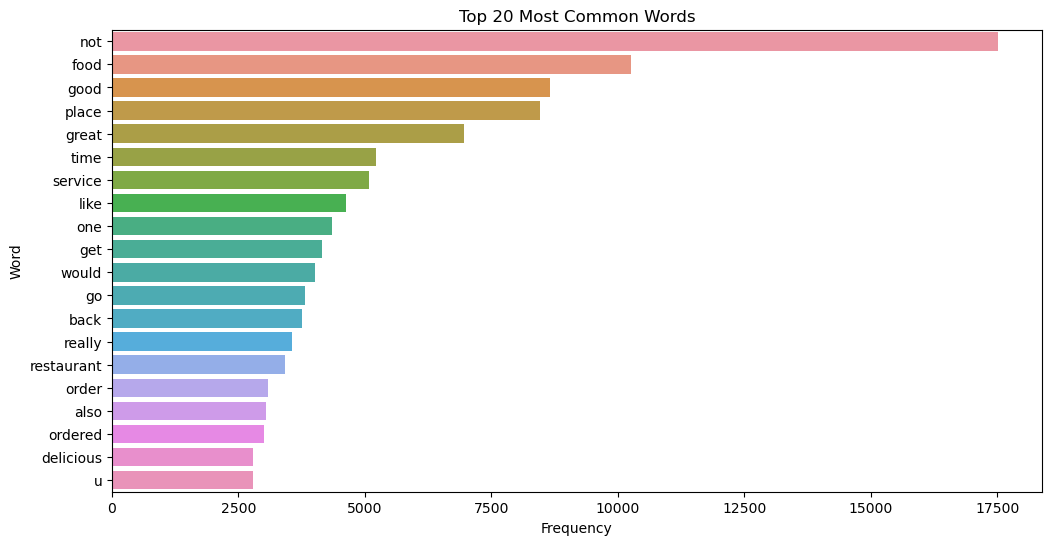

In [15]:
words = [word for word, count in most_common_words]
counts = [count for word, count in most_common_words]

plt.figure(figsize=(12, 6))

sns.barplot(
    x=counts,
    y=words
)

plt.title("Top 20 Most Common Words")
plt.xlabel("Frequency")
plt.ylabel("Word")

plt.show()

### Positive review vocabulary

In [16]:
positive_reviews = df[
    df["rating_review"] == "Positive"
]["clean_text"]

positive_words = " ".join(positive_reviews).split()

positive_word_counts = Counter(positive_words)

positive_common = positive_word_counts.most_common(20)

print(positive_common)

[('not', 8653), ('food', 6409), ('good', 5837), ('great', 5836), ('place', 5776), ('service', 3157), ('time', 3129), ('one', 2653), ('like', 2633), ('get', 2563), ('delicious', 2502), ('go', 2458), ('really', 2312), ('best', 2299), ('back', 2279), ('also', 2228), ('restaurant', 2156), ('would', 2102), ('love', 1940), ('chicken', 1835)]


### Negative review vocabulary

In [17]:
negative_reviews = df[
    df["rating_review"] == "Negative"
]["clean_text"]

negative_words = " ".join(negative_reviews).split()

negative_word_counts = Counter(negative_words)

negative_common = negative_word_counts.most_common(20)

print(negative_common)

[('not', 5690), ('food', 2386), ('place', 1587), ('time', 1324), ('good', 1249), ('no', 1223), ('service', 1168), ('would', 1167), ('like', 1165), ('order', 1139), ('one', 1094), ('u', 1088), ('get', 1044), ('back', 1008), ('ordered', 955), ('table', 907), ('go', 838), ('restaurant', 824), ('came', 754), ('got', 744)]


### Neutral review vocabulary

In [18]:
neutral_reviews = df[
    df["rating_review"] == "Neutral"
]["clean_text"]

neutral_words = " ".join(neutral_reviews).split()

neutral_word_counts = Counter(neutral_words)

neutral_common = neutral_word_counts.most_common(20)

print(neutral_common)

[('not', 3163), ('good', 1575), ('food', 1473), ('place', 1094), ('like', 828), ('time', 758), ('would', 752), ('service', 747), ('really', 603), ('great', 597), ('one', 594), ('get', 541), ('go', 511), ('ordered', 504), ('back', 477), ('order', 473), ('restaurant', 446), ('pretty', 437), ('nice', 433), ('table', 387)]


### Display positive words

In [19]:
positive_common

[('not', 8653),
 ('food', 6409),
 ('good', 5837),
 ('great', 5836),
 ('place', 5776),
 ('service', 3157),
 ('time', 3129),
 ('one', 2653),
 ('like', 2633),
 ('get', 2563),
 ('delicious', 2502),
 ('go', 2458),
 ('really', 2312),
 ('best', 2299),
 ('back', 2279),
 ('also', 2228),
 ('restaurant', 2156),
 ('would', 2102),
 ('love', 1940),
 ('chicken', 1835)]

In [20]:
negative_common

[('not', 5690),
 ('food', 2386),
 ('place', 1587),
 ('time', 1324),
 ('good', 1249),
 ('no', 1223),
 ('service', 1168),
 ('would', 1167),
 ('like', 1165),
 ('order', 1139),
 ('one', 1094),
 ('u', 1088),
 ('get', 1044),
 ('back', 1008),
 ('ordered', 955),
 ('table', 907),
 ('go', 838),
 ('restaurant', 824),
 ('came', 754),
 ('got', 744)]

In [21]:
neutral_common

[('not', 3163),
 ('good', 1575),
 ('food', 1473),
 ('place', 1094),
 ('like', 828),
 ('time', 758),
 ('would', 752),
 ('service', 747),
 ('really', 603),
 ('great', 597),
 ('one', 594),
 ('get', 541),
 ('go', 511),
 ('ordered', 504),
 ('back', 477),
 ('order', 473),
 ('restaurant', 446),
 ('pretty', 437),
 ('nice', 433),
 ('table', 387)]

### Compare Positive vs Negative vocabulary

In [22]:
positive_word_set = set(positive_words)
negative_word_set = set(negative_words)

common_words = positive_word_set.intersection(negative_word_set)

print("Number of common words:", len(common_words))

Number of common words: 7916


### Save the EDA dataset

In [23]:
output_path = "../data/processed/yelp_reviews_eda.csv"

df.to_csv(output_path, index=False)

print("EDA dataset saved successfully.")

EDA dataset saved successfully.


### Phase 4 — NLP EDA: Part 2

### Visualize Positive words

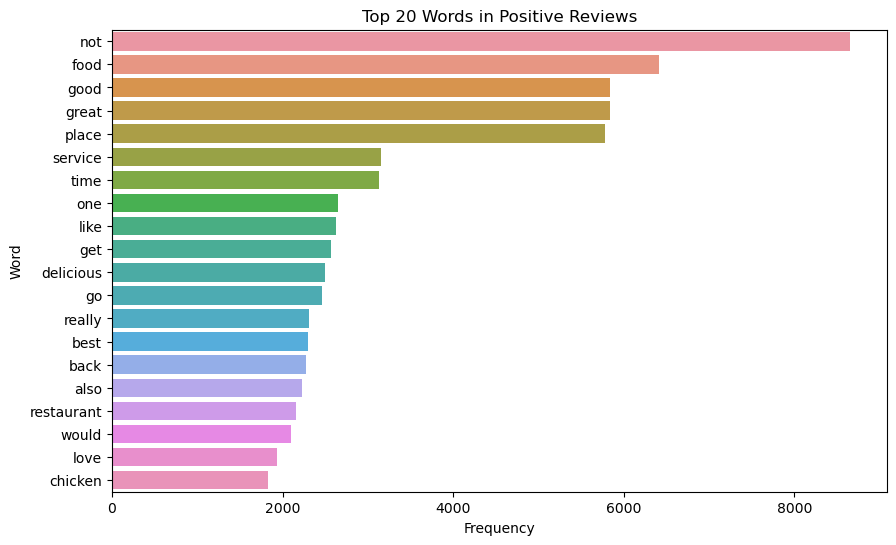

In [24]:
positive_words_df = pd.DataFrame(
    positive_common,
    columns=["word", "frequency"]
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=positive_words_df,
    x="frequency",
    y="word"
)

plt.title("Top 20 Words in Positive Reviews")
plt.xlabel("Frequency")
plt.ylabel("Word")

plt.show()

### Visualize Negative words

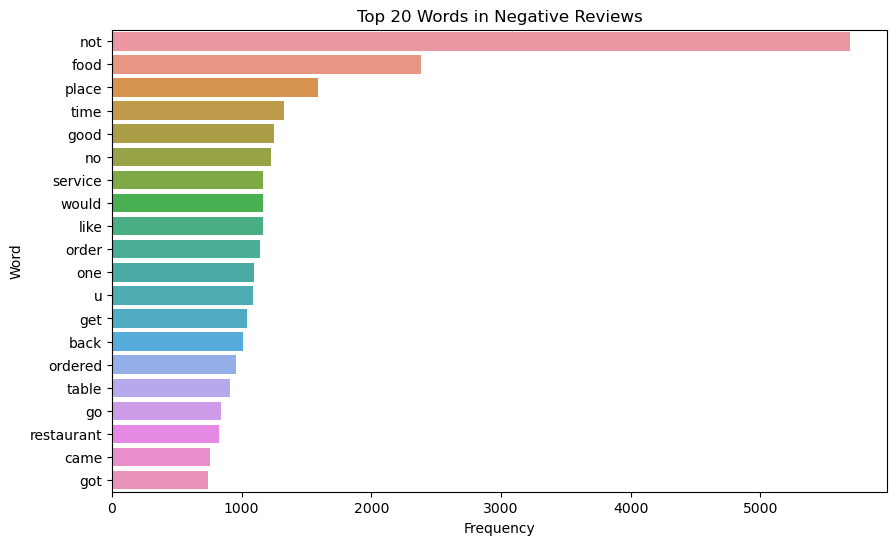

In [26]:
negative_words_df = pd.DataFrame(
    negative_common,
    columns=["word", "frequency"]
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=negative_words_df,
    x="frequency",
    y="word"
)

plt.title("Top 20 Words in Negative Reviews")
plt.xlabel("Frequency")
plt.ylabel("Word")

plt.show()

### Visualize Neutral words

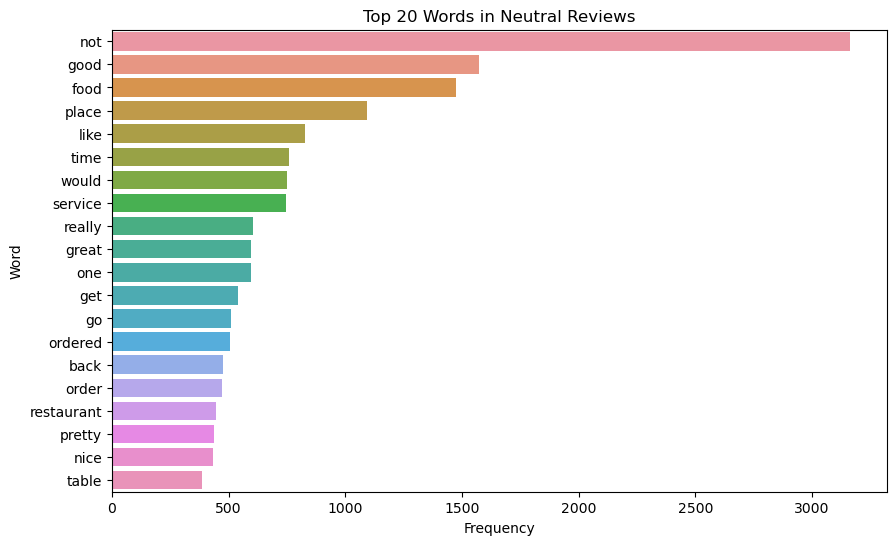

In [27]:
neutral_words_df = pd.DataFrame(
    neutral_common,
    columns=["word", "frequency"]
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=neutral_words_df,
    x="frequency",
    y="word"
)

plt.title("Top 20 Words in Neutral Reviews")
plt.xlabel("Frequency")
plt.ylabel("Word")

plt.show()

### Analyze Bigrams

In [28]:
from collections import Counter

def get_bigrams(text_series):
    words = " ".join(text_series).split()
    
    bigrams = [
        (words[i], words[i + 1])
        for i in range(len(words) - 1)
    ]
    
    return Counter(bigrams)

### Overall top 20 bigrams

In [29]:
overall_bigrams = get_bigrams(df["clean_text"])

top_bigrams = overall_bigrams.most_common(20)

print(top_bigrams)

[(('go', 'back'), 664), (('could', 'not'), 628), (('really', 'good'), 556), (('first', 'time'), 554), (('food', 'good'), 547), (('great', 'food'), 526), (('would', 'not'), 519), (('come', 'back'), 490), (('not', 'even'), 462), (('next', 'time'), 446), (('good', 'food'), 446), (('pretty', 'good'), 443), (('ive', 'ever'), 428), (('great', 'service'), 426), (('not', 'get'), 417), (('food', 'great'), 417), (('happy', 'hour'), 405), (('im', 'not'), 402), (('not', 'know'), 396), (('highly', 'recommend'), 391)]


### Make bigrams readable

In [30]:
top_bigrams_readable = [
    (" ".join(bigram), count)
    for bigram, count in top_bigrams
]

print(top_bigrams_readable)

[('go back', 664), ('could not', 628), ('really good', 556), ('first time', 554), ('food good', 547), ('great food', 526), ('would not', 519), ('come back', 490), ('not even', 462), ('next time', 446), ('good food', 446), ('pretty good', 443), ('ive ever', 428), ('great service', 426), ('not get', 417), ('food great', 417), ('happy hour', 405), ('im not', 402), ('not know', 396), ('highly recommend', 391)]


### Visualize top bigrams

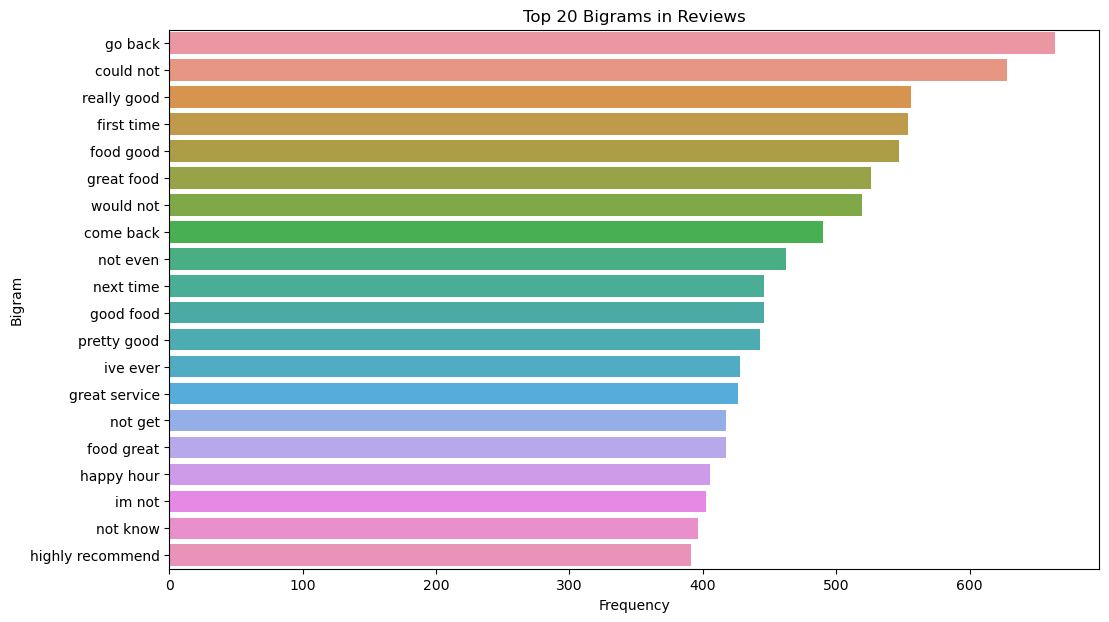

In [31]:
bigrams_df = pd.DataFrame(
    top_bigrams_readable,
    columns=["bigram", "frequency"]
)

plt.figure(figsize=(12, 7))

sns.barplot(
    data=bigrams_df,
    x="frequency",
    y="bigram"
)

plt.title("Top 20 Bigrams in Reviews")
plt.xlabel("Frequency")
plt.ylabel("Bigram")

plt.show()

### Positive bigrams

In [32]:
positive_bigrams = get_bigrams(positive_reviews)

top_positive_bigrams = positive_bigrams.most_common(20)

top_positive_bigrams_readable = [
    (" ".join(bigram), count)
    for bigram, count in top_positive_bigrams
]

print(top_positive_bigrams_readable)

[('great food', 468), ('really good', 430), ('go back', 400), ('highly recommend', 376), ('great service', 375), ('first time', 368), ('food great', 367), ('ive ever', 344), ('food good', 326), ('good food', 325), ('great place', 322), ('could not', 318), ('come back', 318), ('next time', 314), ('love place', 309), ('happy hour', 308), ('service great', 303), ('new orleans', 285), ('not wait', 280), ('ice cream', 263)]


### Negative bigrams

In [33]:
negative_bigrams = get_bigrams(negative_reviews)

top_negative_bigrams = negative_bigrams.most_common(20)

top_negative_bigrams_readable = [
    (" ".join(bigram), count)
    for bigram, count in top_negative_bigrams
]

print(top_negative_bigrams_readable)

[('not even', 266), ('could not', 242), ('would not', 233), ('not good', 166), ('go back', 159), ('food not', 148), ('not know', 141), ('customer service', 137), ('tasted like', 126), ('not get', 124), ('first time', 119), ('not go', 114), ('not worth', 111), ('not back', 101), ('no one', 94), ('not sure', 91), ('come back', 91), ('place not', 90), ('going back', 89), ('food good', 88)]


### Neutral bigrams

In [34]:
neutral_bigrams = get_bigrams(neutral_reviews)

top_neutral_bigrams = neutral_bigrams.most_common(20)

top_neutral_bigrams_readable = [
    (" ".join(bigram), count)
    for bigram, count in top_neutral_bigrams
]

print(top_neutral_bigrams_readable)

[('pretty good', 140), ('food good', 132), ('not bad', 131), ('would not', 112), ('go back', 105), ('good not', 88), ('really good', 85), ('not good', 81), ('come back', 81), ('next time', 80), ('im not', 78), ('not great', 76), ('food not', 72), ('not really', 69), ('good food', 69), ('could not', 68), ('first time', 68), ('not get', 67), ('not know', 65), ('not sure', 65)]


### Analyze Trigrams

In [35]:
def get_trigrams(text_series):
    words = " ".join(text_series).split()
    
    trigrams = [
        (words[i], words[i + 1], words[i + 2])
        for i in range(len(words) - 2)
    ]
    
    return Counter(trigrams)

### Overall top trigrams

In [36]:
overall_trigrams = get_trigrams(df["clean_text"])

top_trigrams = overall_trigrams.most_common(20)

top_trigrams_readable = [
    (" ".join(trigram), count)
    for trigram, count in top_trigrams
]

print(top_trigrams_readable)

[('im not sure', 106), ('not go wrong', 102), ('best ive ever', 96), ('not wait go', 91), ('food great service', 91), ('definitely go back', 89), ('great food great', 89), ('sweet potato fry', 86), ('wait go back', 85), ('would definitely recommend', 79), ('mac n cheese', 78), ('definitely come back', 73), ('would go back', 69), ('not go back', 65), ('next time im', 65), ('service great food', 64), ('food really good', 62), ('would highly recommend', 55), ('not going back', 54), ('could not even', 53)]


### Positive trigrams

In [37]:
positive_trigrams = get_trigrams(positive_reviews)

top_positive_trigrams = positive_trigrams.most_common(20)

top_positive_trigrams_readable = [
    (" ".join(trigram), count)
    for trigram, count in top_positive_trigrams
]

print(top_positive_trigrams_readable)

[('not go wrong', 98), ('not wait go', 90), ('best ive ever', 88), ('great food great', 86), ('wait go back', 85), ('food great service', 84), ('definitely go back', 79), ('would definitely recommend', 75), ('definitely come back', 70), ('sweet potato fry', 67), ('next time im', 53), ('service great food', 53), ('highly recommend place', 52), ('mac n cheese', 52), ('im not sure', 51), ('would highly recommend', 51), ('definitely coming back', 48), ('food really good', 47), ('not say enough', 44), ('would go back', 43)]


### Negative trigrams

In [38]:
negative_trigrams = get_trigrams(negative_reviews)

top_negative_trigrams = negative_trigrams.most_common(20)

top_negative_trigrams_readable = [
    (" ".join(trigram), count)
    for trigram, count in top_negative_trigrams
]

print(top_negative_trigrams_readable)

[('not going back', 51), ('not go back', 49), ('would not recommend', 37), ('could not even', 34), ('never go back', 33), ('im not sure', 28), ('not waste time', 25), ('not recommend place', 22), ('food not good', 21), ('not coming back', 20), ('would not go', 20), ('not come back', 19), ('could not eat', 19), ('really wanted like', 17), ('food good not', 16), ('needle say not', 16), ('could not get', 16), ('wanted like place', 15), ('go somewhere else', 15), ('nothing write home', 15)]


### Neutral trigrams

In [39]:
neutral_trigrams = get_trigrams(neutral_reviews)

top_neutral_trigrams = neutral_trigrams.most_common(20)

top_neutral_trigrams_readable = [
    (" ".join(trigram), count)
    for trigram, count in top_neutral_trigrams
]

print(top_neutral_trigrams_readable)

[('im not sure', 27), ('good not great', 21), ('food good not', 19), ('food pretty good', 18), ('not bad not', 18), ('would go back', 18), ('nothing write home', 18), ('would not go', 17), ('mac n cheese', 14), ('not go back', 13), ('not go way', 13), ('not get wrong', 13), ('sweet potato fry', 13), ('not bad place', 12), ('cafe du monde', 11), ('food not bad', 11), ('seated right away', 10), ('food good service', 10), ('definitely go back', 10), ('go back try', 10)]


### 